# CSD sanity-check notebook

Quick visual and amplitude diagnostics for Current Source Density (CSD) epochs.
- Select a CSD epochs folder (e.g., `data/epochs/sliding_window15s_stride15s_csd`)
- Plot a few epochs with stacked channels (decimated for speed)
- Compute basic per-channel amplitude stats and flag near-flat channels

In [13]:
# Imports and small utilities
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import mne
import pandas as pd

def get_project_root() -> Path:
    """Resolve repo root both from scripts and notebooks."""
    try:
        return Path(__file__).resolve().parents[1]  # running as a script
    except NameError:
        cwd = Path.cwd().resolve()                  # running in a notebook
        return cwd.parent if cwd.name == 'notebooks' else cwd

ROOT = get_project_root()
print(f'Repo root: {ROOT}')

Repo root: \\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor


In [14]:
# Configuration (edit here)
INPUT_DIR = ROOT / 'data' / 'epochs' / 'sliding_window15s_stride15s_csd'  # change if needed
GLOB = '*.fif'            # match CSD epochs files
MAX_FILES = 1             # how many files to inspect
N_EPOCHS_PREVIEW = 6      # plot up to this many epochs
N_CHANNELS = 16           # plot up to this many EEG channels
PLOT_SF_HZ = 60.0         # target plotting sampling rate via decimation
NEAR_ZERO_STD_UV = 0.5    # threshold for near-flat channels (µV-equivalent units)

INPUT_DIR = Path(INPUT_DIR)
print(f'Looking for CSD epochs in: {INPUT_DIR}')
assert INPUT_DIR.exists(), 'INPUT_DIR does not exist'
files = sorted(INPUT_DIR.rglob(GLOB))
print(f'Matched {len(files)} file(s)')
assert len(files) > 0, 'No CSD epochs files found'
if isinstance(MAX_FILES, int) and MAX_FILES > 0:
    files = files[:MAX_FILES]
files

Looking for CSD epochs in: \\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\epochs\sliding_window15s_stride15s_csd
Matched 45 file(s)


[WindowsPath('//regionh.top.local/dfs/Logget/AuditData/CONNECT-ME/Bjoern/eeg-bachelor/data/epochs/sliding_window15s_stride15s_csd/patient36_raw_csd-epo.fif')]

In [15]:
# Load the first epochs file and summarize
ep_path = files[0]
print(f'Loading: {ep_path.name}')
epochs = mne.read_epochs(ep_path, preload=True, verbose='ERROR')
sfreq = float(epochs.info.get('sfreq', 0.0))

# Prefer EEG channels; if none found, fall back to all non-stim channels
picks = mne.pick_types(epochs.info, eeg=True, meg=False, eog=False, ecg=False, stim=False, exclude=[])
if len(picks) == 0:
    types = epochs.get_channel_types()
    picks = np.array([i for i, t in enumerate(types) if t != 'stim'])
    print(f"No EEG-type channels found; falling back to non-stim channels (n={len(picks)}).")

ch_names = [epochs.ch_names[i] for i in picks]
print(f'n_epochs={len(epochs)}, sfreq={sfreq}, n_data_ch={len(picks)}')
print('First 20 data channels:', ch_names[:20])

Loading: patient36_raw_csd-epo.fif


No EEG-type channels found; falling back to non-stim channels (n=19).
n_epochs=364, sfreq=250.0, n_data_ch=19
First 20 data channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']


## Amplitude stats and near-flat channel flags
We compute per-channel standard deviation (over all selected epochs/time) and flag channels below a small threshold.
Note: After CSD, values are in transformed units (not raw µV). We use "µV-equivalent" scaling (×1e6) only for readability.

In [16]:
# Compute per-channel std and peak-to-peak across all epochs (data channels)
if len(picks) == 0:
    # As a last resort, consider all channels except stim
    types = epochs.get_channel_types()
    picks = np.array([i for i, t in enumerate(types) if t != 'stim'])
    print(f"Rebuilt picks (non-stim): n={len(picks)}")

data = epochs.get_data(picks=picks)  # shape: (n_epochs, n_ch, n_times)
n_ep, n_ch, n_t = data.shape

# Collapse (epochs,time) so stats are across all samples per channel
data_all = data.transpose(1, 0, 2).reshape(n_ch, -1)

# µV-equivalent for readability
std_uv = data_all.std(axis=1, ddof=1) * 1e6
ptp_uv = (data_all.max(axis=1) - data_all.min(axis=1)) * 1e6

# Build stats table
stats_df = (
    pd.DataFrame({
        "channel": [epochs.ch_names[i] for i in picks],
        "std_uv": std_uv,
        "ptp_uv": ptp_uv,
    })
    .sort_values("std_uv")
    .reset_index(drop=True)
)

# Flag near-flat channels
flags = stats_df["std_uv"] < float(NEAR_ZERO_STD_UV)
print(f"Channels flagged near-flat (< {NEAR_ZERO_STD_UV} µV): {int(flags.sum())}")

# Preview
display(stats_df.head(10))
display(stats_df[flags])

Channels flagged near-flat (< 0.5 µV): 0


,channel,std_uv,ptp_uv
0,F4,23497.837063,1.390062e+06
1,F3,27135.894894,1.676865e+06
2,Fz,28194.093956,2.332857e+06
3,P4,29835.006602,2.038048e+06
4,Pz,32337.096786,2.417696e+06
5,C4,34893.127417,2.366601e+06
6,T8,35275.443194,2.689528e+06
7,F8,35842.652823,2.673443e+06
8,Fp2,38913.234187,2.679047e+06
9,F7,39408.175369,3.810967e+06


,channel,std_uv,ptp_uv


## Plot a few epochs (stacked traces)
Plots are decimated to ~PLOT_SF_HZ for responsiveness.

Using decimation factor: 4 (target ~60.0 Hz)


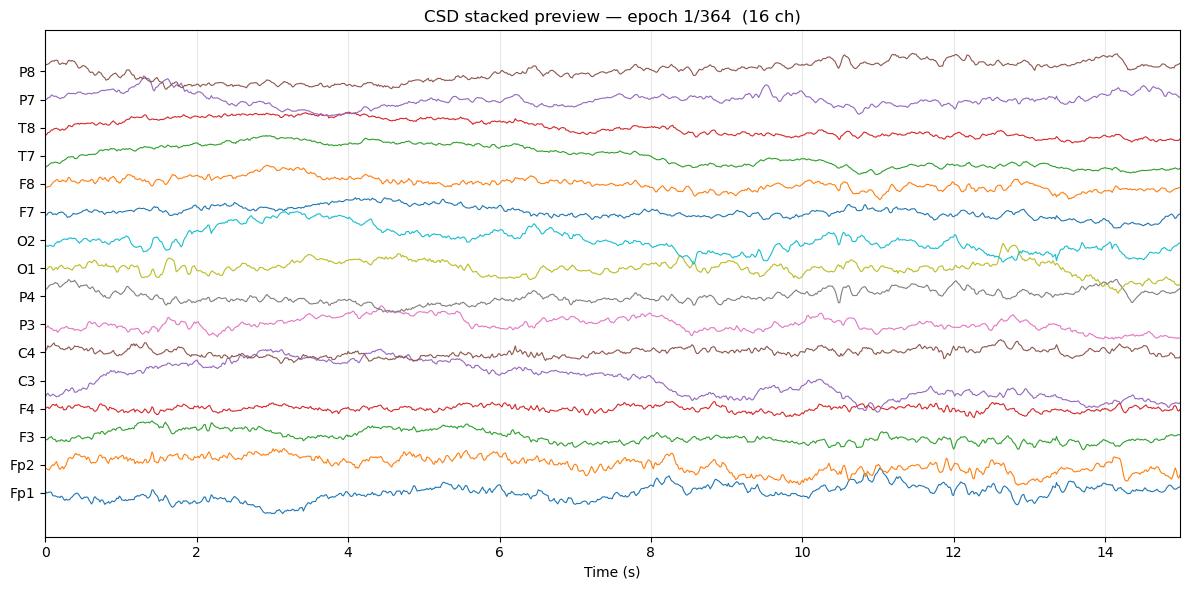

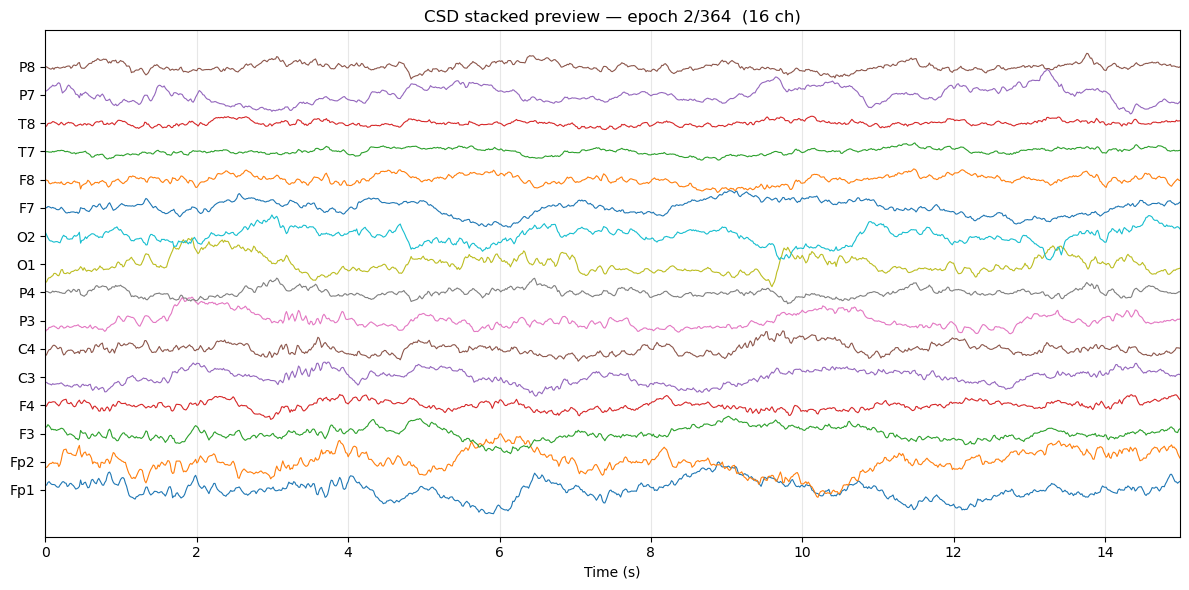

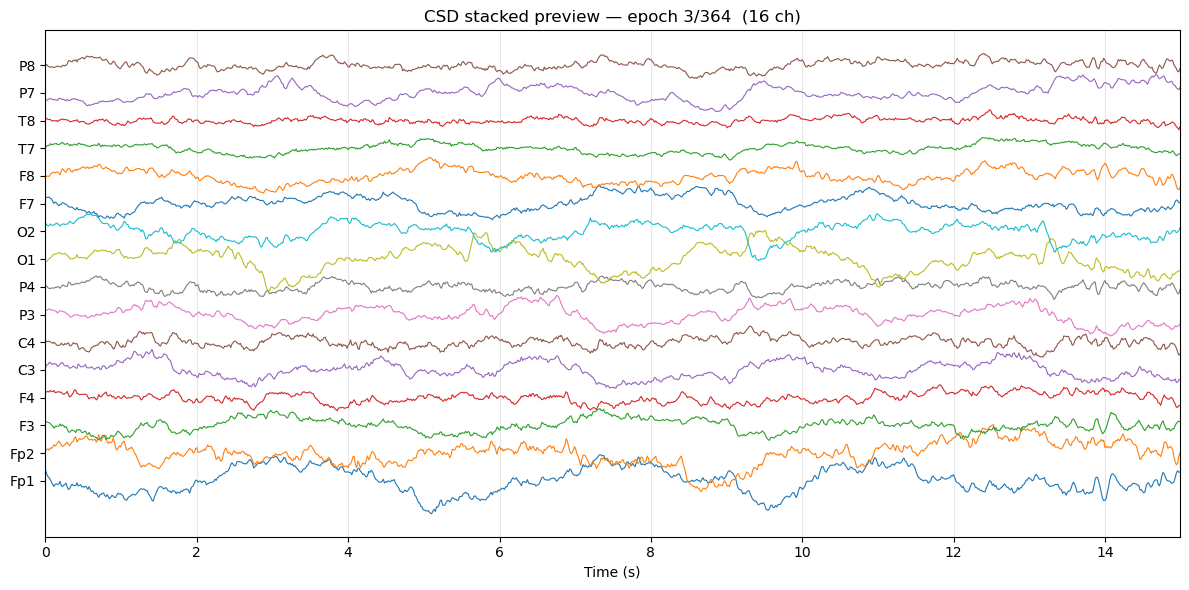

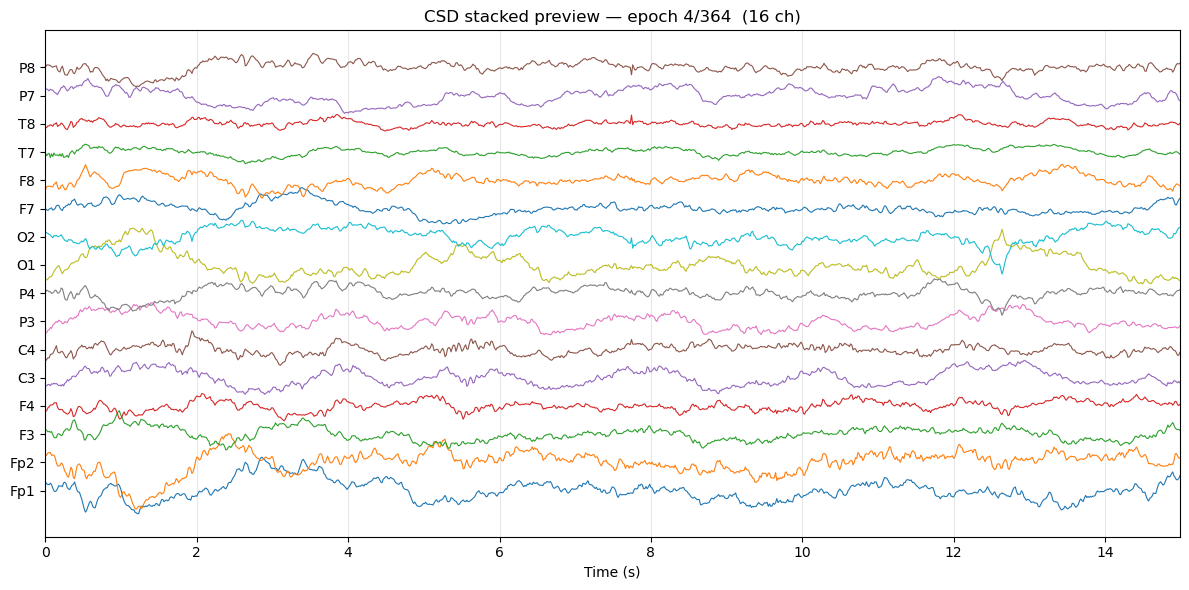

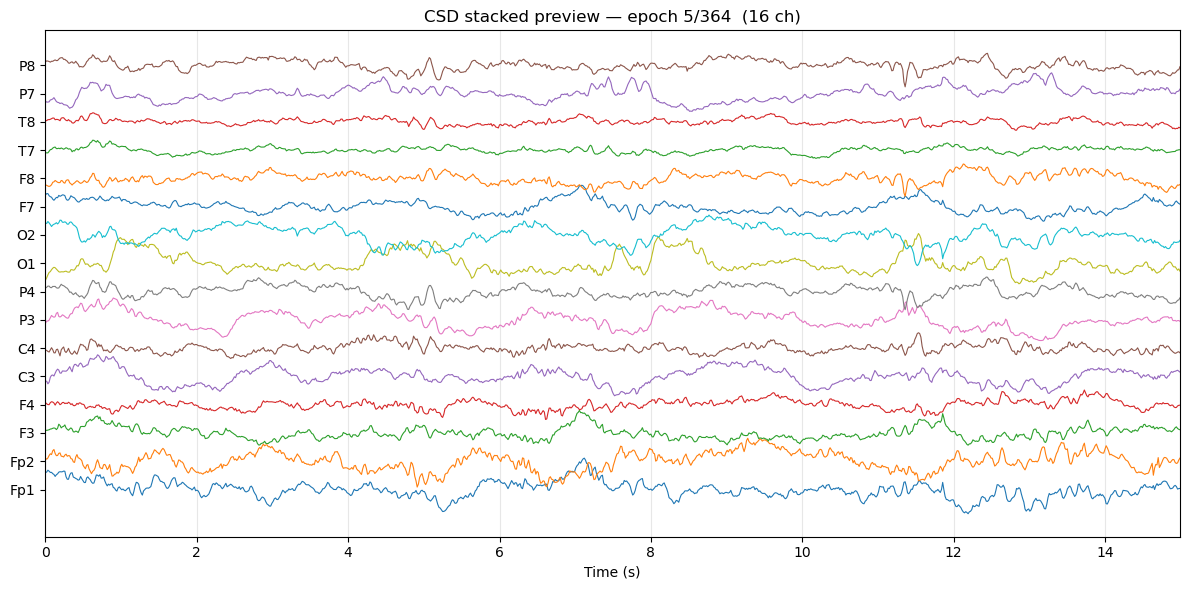

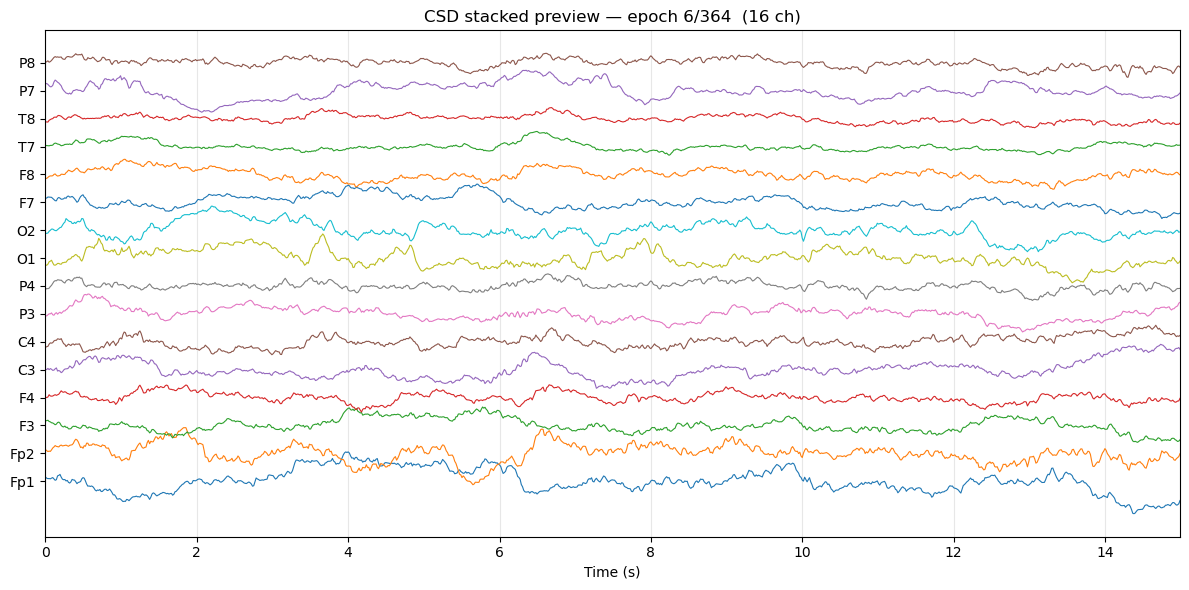

In [17]:
# Basic stacked plot of a few epochs
if len(picks) == 0:
    raise RuntimeError('No EEG channels found to plot.')
p_sel = picks[:min(N_CHANNELS, len(picks))]
chs_sel = [epochs.ch_names[i] for i in p_sel]

sf = sfreq if sfreq > 0 else 1.0
decim = max(1, int(round(sf / float(PLOT_SF_HZ))))
print(f'Using decimation factor: {decim} (target ~{PLOT_SF_HZ} Hz)')

n_show = min(int(N_EPOCHS_PREVIEW), len(epochs))
for i in range(n_show):
    seg = epochs.get_data(picks=p_sel)[i] * 1e6  # µV-equivalent
    if decim > 1:
        seg = seg[:, ::decim]
    seg = seg - seg.mean(axis=1, keepdims=True)
    n_ch, n_samp = seg.shape
    t = np.arange(n_samp) * (decim / sf)

    # Robust gap: median of channel peak-to-peak, fallback to 50 µV
    ptp_per_ch = np.ptp(seg, axis=1)
    gap = float(np.median(ptp_per_ch) * 0.8) if np.isfinite(ptp_per_ch).all() else 50.0
    gap = gap if gap > 1e-6 else 50.0

    fig, ax = plt.subplots(figsize=(12, 6))
    for ci in range(n_ch):
        ax.plot(t, seg[ci] + ci * gap, lw=0.8)
    ax.set_title(f'CSD stacked preview — epoch {i+1}/{len(epochs)}  ({n_ch} ch)')
    ax.set_xlabel('Time (s)')
    ax.set_yticks([ci * gap for ci in range(n_ch)])
    ax.set_yticklabels(chs_sel)
    ax.grid(True, axis='x', alpha=0.3)
    if n_samp > 0:
        ax.set_xlim(t[0], t[-1])
    plt.tight_layout()
    plt.show()
    plt.close(fig)

## Verify CSD vs original epochs
This section loads the matching original (non-CSD) epochs file for the current CSD file and performs quick checks:
- Confirms both files exist and have compatible shapes
- Computes a simple sample correlation to ensure the CSD data differ from the original
- Prints a short summary


In [18]:
# Compare current CSD epochs to original (non-CSD)
from pathlib import Path

# Current CSD epochs and directory inferred from ep_path / INPUT_DIR
try:
    csd_dir = ep_path.parent
except NameError:
    # If ep_path wasn't created yet, rebuild from INPUT_DIR
    _files = sorted(Path(INPUT_DIR).rglob(GLOB))
    assert len(_files) > 0, "No CSD epochs files to compare."
    ep_path = _files[0]
    csd_dir = ep_path.parent

orig_dir = csd_dir.with_name(csd_dir.name.replace('_csd', ''))
orig_file = orig_dir / ep_path.name.replace('_csd-epo.fif', '-epo.fif')

print(f"CSD file:   {ep_path}")
print(f"Original:    {orig_file}")

if not orig_file.exists():
    raise FileNotFoundError(f"Original epochs not found: {orig_file}")

# Load both
ep_csd = epochs  # current CSD epochs already loaded above
ep_orig = mne.read_epochs(orig_file, preload=True, verbose='ERROR')

# Align channels by name intersection
names_common = [ch for ch in ep_csd.ch_names if ch in ep_orig.ch_names]
idx_csd  = mne.pick_channels(ep_csd.ch_names, names_common)
idx_orig = mne.pick_channels(ep_orig.ch_names, names_common)

Xc = ep_csd.get_data(picks=idx_csd)
Xo = ep_orig.get_data(picks=idx_orig)
print("shapes (orig, csd):", Xo.shape, Xc.shape)

# Simple difference check on one channel/epoch
i_ep = 0 if len(Xc) > 0 else None
i_ch = 0 if Xc.shape[1] > 0 else None
if i_ep is None or i_ch is None:
    print("No data available to compare.")
else:
    a = Xo[i_ep, i_ch]
    b = Xc[i_ep, i_ch]
    if a.std() == 0 or b.std() == 0:
        print("One of the signals is constant; skipping correlation.")
    else:
        r = np.corrcoef(a.ravel(), b.ravel())[0, 1]
        print(f"sample corr (epoch {i_ep}, ch {names_common[i_ch]}): {r:.4f}")
        print("Expect < 1.0 if CSD changed the data.")


CSD file:   \\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\epochs\sliding_window15s_stride15s_csd\patient36_raw_csd-epo.fif
Original:    \\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\epochs\sliding_window15s_stride15s\patient36_raw-epo.fif
shapes (orig, csd): (364, 19, 3750) (364, 19, 3750)
sample corr (epoch 0, ch Fp1): 0.9584
Expect < 1.0 if CSD changed the data.
shapes (orig, csd): (364, 19, 3750) (364, 19, 3750)
sample corr (epoch 0, ch Fp1): 0.9584
Expect < 1.0 if CSD changed the data.
